In [24]:
using Plots
using LaTeXStrings
using Statistics
include("../fft.jl")
include("zoom.jl")

zoom_plot (generic function with 4 methods)

In [25]:
function centered_disks(N; disk_scale=1)
    """
        Create a centered disk aperture of size N x N
    """
    upper = (N-1)/2 + 0.1
    lower = (-N+1)/2
    x = collect(lower:1:upper)
    y = collect(lower:1:upper)

    r = @. sqrt(x'^2 + y^2)
    disk = r.<=N/2/disk_scale
end



centered_disks (generic function with 1 method)

In [26]:

function Periodic_Peaks(y::AbstractVector)
    # autocorr = abs.(ifft2(fft2(prob2d).*conj.(fft2(prob2d)) ) )
    N = length(y)
    threshold = maximum(y)/10
    y_diff = diff(y)
    peaks = Int[]


    for i in 1:(N-2)
        if (y_diff[i+1]*y_diff[i] < 0) && (y[i+1] > threshold)
            push!(peaks, i+1)
        end
    end

    
    if length(peaks) > 1
        peak_spacing = round(Int, median(diff(peaks)))
    else
        @error "no peaks found"
    end

    post = collect(peaks[end]+peak_spacing:peak_spacing:N)
    pre = collect(peaks[1]-peak_spacing:-peak_spacing:1)
    peaks = vcat(reverse(pre), peaks, post)

    return peaks, peak_spacing
end




function mode_probabilities(image, normalize=true)
    if normalize
        image ./= sqrt(sum(abs2,image))
    end
    y = vec(sum(abs2, image, dims=1))
    N = length(y)

    peaks, peak_spacing = Periodic_Peaks(y)
    if peak_spacing == 0
        return
    end
    println(peak_spacing)
    peak_masks = [begin
                    mask = falses(N)
                    mask[clamp(peak_idx - peak_spacing ÷ 2, 1, N):clamp(peak_idx + cld(peak_spacing, 2) - 1, 1, N)] .= true
                    mask
                end for peak_idx in peaks]
    
    mode_probs = [sum(y[mask]) for mask in peak_masks]
    return mode_probs, peak_masks
end

function transmission_func(g; aperature=true)
    #given
    σU = 0.15 
    α = 0.008 
    disk = centered_disks(size(g,1)) 
    if aperature
        t = @. cis((σU + 1im * α)*g/10 * disk) * disk
    else
        t = @. cis((σU + 1im * α)*g/10)
    end

    return t
end


function FC_of_gratings(g, aperature=true)
    """
        This function does not account for aperatures
    """
    t = transmission_func(g; aperature=aperature)
    fft_t = fft2(t)
    return fft_t, mode_probabilities(fft_t)[1]
end


FC_of_gratings (generic function with 2 methods)

In [27]:
function plot_grating(g::AbstractMatrix, name::String="")
    Ny, Nx = size(g)
    g = abs.(g)
    fig1 = heatmap(
        g,
        aspect_ratio = 1,
        colorbar = false,
        title = "$(name) grating",
        xlabel = "",
        ylabel = "",
        xlim = (0, Nx),
        ylim = (0, Ny),
    )

    fig2 = plot(
        g[Ny÷2, :],
        title = "Cross-section of $(name) grating",   # <- interpolate name here
        xlabel = "",
        ylabel = "Height (Angstroms)",
        ylim = (250, maximum(g)*1.1),
    )

    
    fft_grating, mode_probs = FC_of_gratings(g,true)
    
    ctr = length(mode_probs)÷2 + 1
    width = 5
    modes = ctr-width:1:ctr+width
    xtick_positions = collect(modes)
    xtick_labels = string.(modes .- ctr)
    fig3 = bar(
        modes,
        mode_probs[modes],
        xticks=(xtick_positions, xtick_labels),
        xlabel="", 
        ylabel="", 
        title="Mode probabilities"
    )


    fig4 = zoom_heatmap(
        abs.(fft_grating), 
        70, 
        colorbar=false,
        ylabel="",
        xlabel=""
    )

    p = plot(fig1, fig2, fig3, fig4;
            layout = (2, 2),
            size = (800, 800)
    )

    display(p)   # ensure notebook shows it
end

plot_grating (generic function with 2 methods)

In [28]:
function blazed_grating(N, p; thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    Ny, Nx = N, N

    xs = (0:Nx-1) ./ Nx                # N points, endpoint 1 is excluded
    d0 = thickness - mill_depth
    g1 = @. mill_depth*mod(p*xs, 1) + d0
    
    g2 = repeat(g1', N, 1)
    return g2
end

function test_grating(N, p, x_apex; thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    Ny, Nx = N, N


    # xs = (0:(Nx÷p)-1) ./ (Nx÷p)                # N/p points, endpoint 1 is excluded
    # d0 = thickness - mill_depth
    # g1 = zeros(Float64, Nx÷p)
    # for (i,x) in enumerate(xs)
    #     if x <= x_apex
    #         g1[i] = mill_depth/x_apex * x  + d0
    #     else
    #         g1[i] = -mill_depth/(1-x_apex) * (x-x_apex) + thickness 
    #     end
    # end

    xs = collect(Int, 0:1:(Nx÷p)-1)                # N/p points, endpoint 1 is excluded
    x_apex = floor(Int, x_apex * xs[end])
    d0 = thickness - mill_depth
    g1 = zeros(Float64, Nx÷p)
    for (i,x) in enumerate(xs)
        if x <= x_apex
            g1[i] = x/(x_apex+1)
        else
            x_shifted = x - (x_apex + 1)
            g1[i] = -x_shifted/(xs[end] - x_apex) + oneunit(Int)
        end
    end
    g1 = @. g1 * mill_depth + d0

    g2 = repeat(g1', N, p)
    return g2
end
function test_grating_1d(N, p, x_apex; thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    
    xs = collect(Int, 0:1:(Nx÷p)-1)                # N/p points, endpoint 1 is excluded
    x_apex = floor(Int, x_apex * xs[end])
    d0 = thickness - mill_depth
    g1 = zeros(Float64, Nx÷p)
    for (i,x) in enumerate(xs)
        if x <= x_apex
            g1[i] = x/(x_apex+1)
        else
            x_shifted = x - (x_apex + 1)
            g1[i] = -x_shifted/(xs[end] - x_apex) + oneunit(Int)
        end
    end
    g1 .= g1 .* mill_depth .+ d0
    return g1
end

function double_blazed_grating(N, p, p2, x_apex; thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    Ny, Nx = N, N


    xs = (0:(Nx÷p)-1) ./ (Nx÷p)                # N/p points, endpoint 1 is excluded
    δx = xs[2] - xs[1]
    d0 = thickness - mill_depth
    g1 = zeros(Float64, Nx÷p)


    Δx = x_apex/2
    y_ratio = p2 / (p + p2)
    m1 = mill_depth*(1 - y_ratio)/Δx
    m2 = mill_depth*y_ratio/Δx

    for (i,x) in enumerate(xs)
        if x <= Δx
            g1[i] = m1 * x  + d0
            
        elseif x <= x_apex
            x_shift = x - Δx
            g1[i] = m2 * x_shift + d0 + mill_depth*(1 - y_ratio)
        else
            g1[i] = -mill_depth/(1-x_apex) * (x-x_apex) + thickness 
        end
    end

    g2 = repeat(g1', N, p)
    return g2
end
function double_blazed_grating(N, p, p2, x_apex; thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    Ny, Nx = N, N


    xs = (0:(Nx÷p)-1) ./ (Nx÷p)                # N/p points, endpoint 1 is excluded
    δx = xs[2] - xs[1]
    d0 = thickness - mill_depth
    g1 = zeros(Float64, Nx÷p)

    n_subs = 2(p + p2)
    x_subs = (0:(Nx÷n_subs)-1) ./ n_subs
    yp = @. mill_depth * x_subs + d0
    yd = @. -mill_depth * x_subs + thickness
    yp2 = @. mill_depth * p2/p * x_subs + d0
    yd2 = @. -mill_depth * p2/p * x_subs + thickness

    g1 = vcat(yp, yd, yp2, yd2, yp2, yd2)


    
    # Δx1 = x_ratio * x_apex
    # Δx2 = x_apex - Δx1
    # y_ratio = p2 / (p + p2)
    # m1 = mill_depth*(1 - y_ratio)/Δx
    # m2 = mill_depth*y_ratio/Δx

    # for (i,x) in enumerate(xs)
    #     if x <= Δx1
    #         g1[i] = m1 * x  + d0
            
    #     elseif x <= x_apex
    #         x_shift = x - Δx
    #         g1[i] = m2 * x_shift + d0 + mill_depth*(1 - y_ratio)
    #     else
    #         g1[i] = -mill_depth/(1-x_apex) * (x-x_apex) + thickness 
    #     end
    # end

    g2 = repeat(g1', N, p)
    return g2
end

using ImageFiltering

function gaussian_grating(N, p, σ; thickness=500, smooth_sigma=0.0)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    Ny, Nx = N, N
    g2 = fill(Float64(thickness), N, N)
    # remove stray `$`, broadcast clamp so types stay consistent
    noise = clamp.(randn(N, N) .* σ, 0.0, 2.0*σ)
    
    # optional Gaussian smoothing (separable, fast)
    if smooth_sigma > 0
        k = KernelFactors.gaussian(smooth_sigma)   # separable kernel
        noise = imfilter(noise, Kernel.gaussian(smooth_sigma), Pad(:reflect))  # choose padding that makes sense for your domain
    end

    g2 .-= noise
    return g2
end

function sinusoidal_grating(N, p; thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    Ny, Nx = N, N

    xs = (0:Nx-1) ./ Nx                # N points, endpoint 1 is excluded
    d0 = thickness - mill_depth
    g1 = @. (mill_depth/2)*(1 .+ sin.(2π*p*xs .- π/2)) + d0
    
    g2 = repeat(g1', N, 1)
    return g2
end

function ellipse_blazed_grating(N, p, x_apex, (qx, qy); thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    Ny, Nx = N, N


    xs = (0:(Nx÷p)-1) ./ (Nx÷p)                # N/p points, endpoint 1 is excluded
    d0 = thickness - mill_depth
    g1 = zeros(Float64, Nx÷p)

    
    a = 1 - x_apex
    b = mill_depth
    for (i,x) in enumerate(xs)
        if x <= x_apex
            g1[i] = mill_depth/x_apex * x  + d0
        else
            g1[i] = b * ( 1 - ((x-x_apex)/a)^qx)^inv(qy) + d0
        end
    end

    g2 = repeat(g1', N, p)
    return g2
end
function tanh_values(N, tanh_slope_cutoff, k)
    x_cutoff_half_width = asech(sqrt(2*tanh_slope_cutoff/k))/k
    x_shift = 1 - x_cutoff_half_width
    xs = (0:N-1) ./ N
    tanh_vals = @. (1/2) * (tanh(-k * (xs - x_shift )) + 1) #smooth flipped heaviside function
    return tanh_vals, 2*x_cutoff_half_width
end

function tanh_blazed_grating(N, p, x_apex, k; thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    Ny, Nx = N, N

    tanh_slope_cutoff = 0.1
    tanh_vals, x_cutoff_width = tanh_values(Nx÷p, tanh_slope_cutoff, k)
    
    @assert x_cutoff_width < 1 - x_apex "k is too small or change cutoff value"

    

    xs = collect(Int, 0:1:(Nx÷p)-1)                # N/p points, endpoint 1 is excluded
    x_apex = floor(Int, x_apex * xs[end])
    d0 = thickness - mill_depth
    g1 = zeros(Float64, Nx÷p)
    for (i,x) in enumerate(xs)
        if x <= x_apex
            g1[i] = x/(x_apex+1)
        else
            g1[i] = tanh_vals[i]
        end
    end
    g1 = @. g1 * mill_depth + d0

    g2 = repeat(g1', N, p)
    return g2, (g1, x_cutoff_width)
end



tanh_blazed_grating (generic function with 1 method)

8
(128,) (128,)
Total pixels in peaks: 1012.0
Total dot product between adjacent peak masks: 0.0


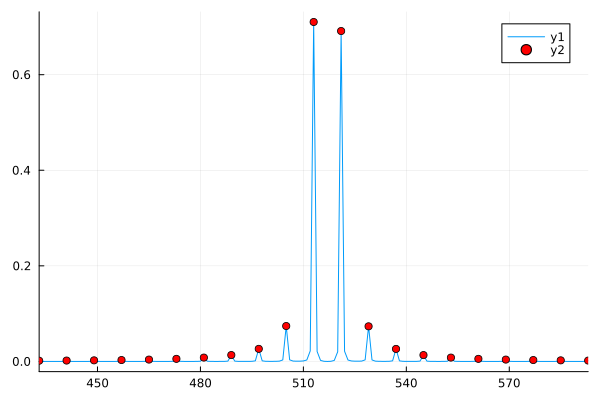

In [30]:
N = 1024
p = 8
ctr = N÷2 + 1
grating_blazed = blazed_grating(N, p)
t_grating = transmission_func(grating_blazed; aperature=true)
t_fft = abs2.(fft2(t_grating))
mode_probs, peak_masks = mode_probabilities(t_fft)
println(size(mode_probs), " ", size(peak_masks))
total = 0.0
total_dot_product = 0.0
for i in 1:(length(peak_masks)-1)
    mask_1 = peak_masks[i]
    mask_2 = peak_masks[i+1]
    total += sum(mask_1)
    total_dot_product += sum(mask_1 .* mask_2)
end
println("Total pixels in peaks: ", total)
println("Total dot product between adjacent peak masks: ", total_dot_product)
y_1d = vec(sum(abs2, t_fft, dims=1))
peaks, peak_spacing = Periodic_Peaks(y_1d)
y_1d = abs.(t_fft[ctr, :])

plot(y_1d)
scatter!(peaks, y_1d[peaks], color=:red)
xlims!(ctr - 10*peak_spacing, ctr + 10*peak_spacing)


4


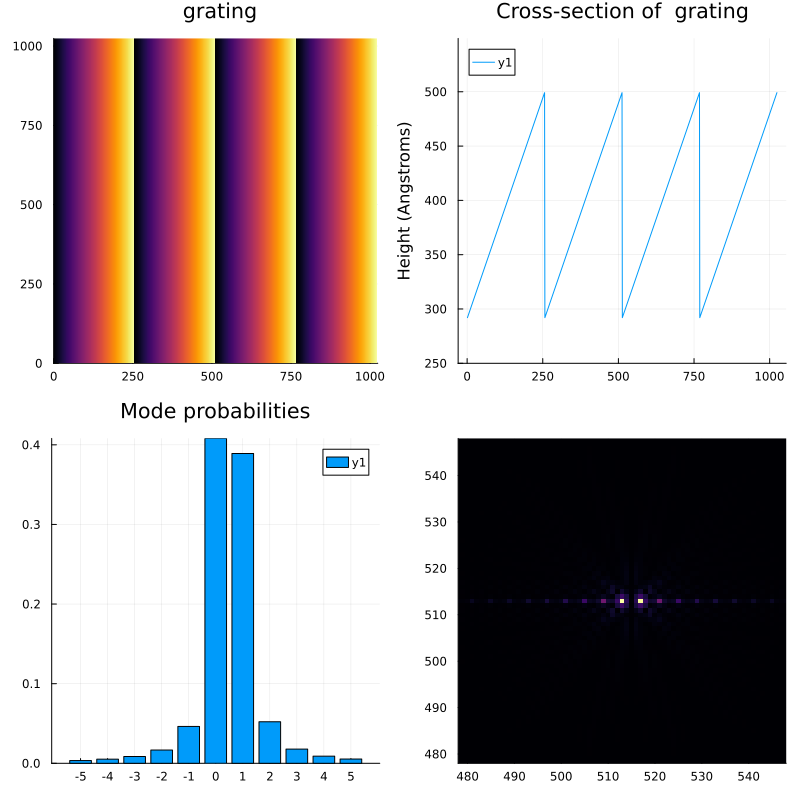

In [31]:
N = 1024
p = 4
grating_blazed = blazed_grating(N, p)
plot_grating(grating_blazed)

4


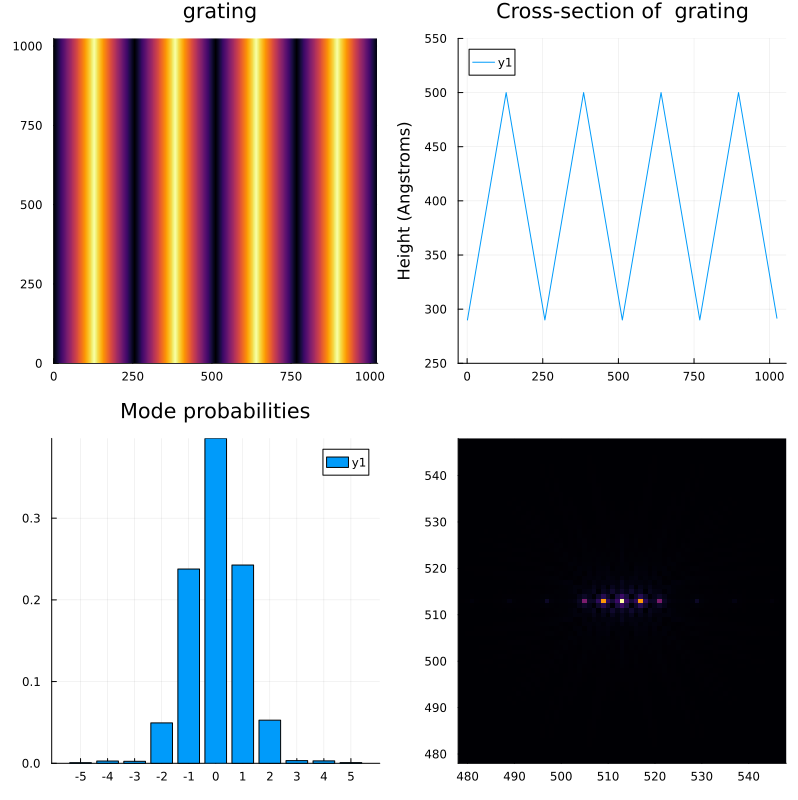

In [32]:

p = 4
grating_test = test_grating(N, p, 0.5; mill_depth=210)
# plot(grating_test[N÷2,:])
plot_grating(grating_test)

In [33]:
#region gaussian probe
N = 2^10
upper = (N-1)/2 + 0.1
lower = (-N+1)/2
x = collect(lower:1:upper)
y = collect(lower:1:upper)

r = @. sqrt(x'^2 + y^2)
disk = r.<=N/2
sigma = 4
gaussian = @. inv(sqrt(2π*sigma^2)) * exp(-r^2 * inv(2 * sigma^2))
gaussian = circshift(gaussian, (0,50))
#endregion

plot_grating(gaussian)

┌ Error: no peaks found
└ @ Main /home/nicolas/Desktop/julia_functions/IFM/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:20


UndefVarError: UndefVarError: `peak_spacing` not defined in local scope
Suggestion: check for an assignment to a local variable that shadows a global of the same name.

In [34]:
plot_grating(gaussian_grating(N, p,100, smooth_sigma=4.0))

┌ Error: no peaks found
└ @ Main /home/nicolas/Desktop/julia_functions/IFM/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:20


UndefVarError: UndefVarError: `peak_spacing` not defined in local scope
Suggestion: check for an assignment to a local variable that shadows a global of the same name.

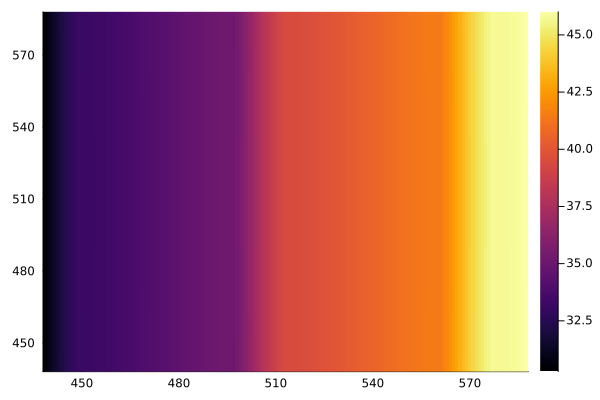

In [35]:
N = 2^10
p = 16
#given
σU = 0.15 
α = 0.008 
grating_test = test_grating(N, p, 0.75; mill_depth=208)

disk = centered_disks(size(grating_test,1)) 
t = @. cis((σU + 1im * α)*grating_test/10 * disk) * disk


fft_t = fft2(t)
mask = repeat(x',N, 1) .> -p÷2
fft_t_masked = @. abs(fft_t) * mask * cis(angle(fft_t) * mask)
fft_t_masked = circshift(fft_t_masked, (0, -p))
t_masked = ifft2(fft_t_masked)
# using Pkg
# Pkg.add(url="https://github.com/platawiec/Unwrap.jl")
using Unwrap
grating_masked = angle.(t_masked)
grating_masked = unwrap(grating_masked)
# grating_masked = mod.(grating_masked, π)


# ψ_2m = @. abs(ψ_2m) * mask * cis(angle(ψ_2m) * mask)
zoom_heatmap(abs.(grating_masked),150)

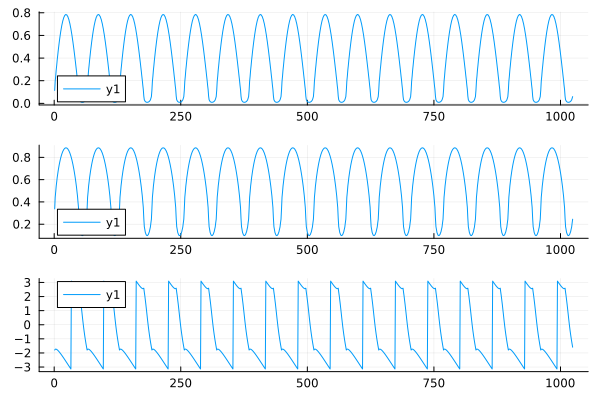

In [36]:
t_masked_slice = t_masked[512,:]
fig1 = plot(abs2.(t_masked_slice))
fig2 = plot(abs.(t_masked_slice))
fig3 = plot(angle.(t_masked_slice))
plot(fig1, fig2, fig3; layout=(3,1))

In [37]:
plot_grating(grating_masked)

┌ Error: no peaks found
└ @ Main /home/nicolas/Desktop/julia_functions/IFM/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:20


UndefVarError: UndefVarError: `peak_spacing` not defined in local scope
Suggestion: check for an assignment to a local variable that shadows a global of the same name.

4


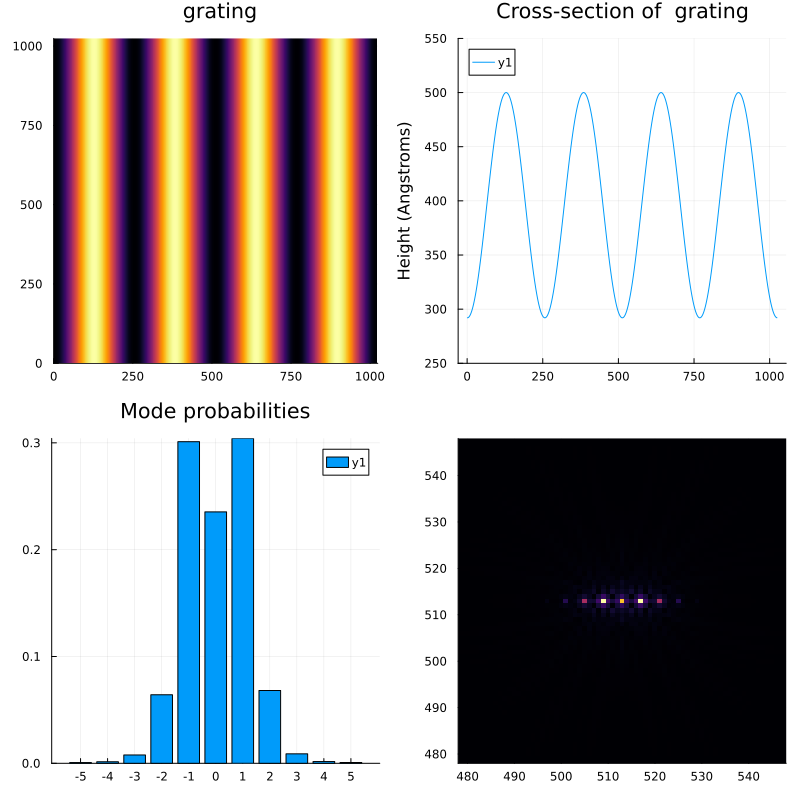

In [38]:
p=4
grating_sinusoidal = sinusoidal_grating(N, p)
plot_grating(grating_sinusoidal)

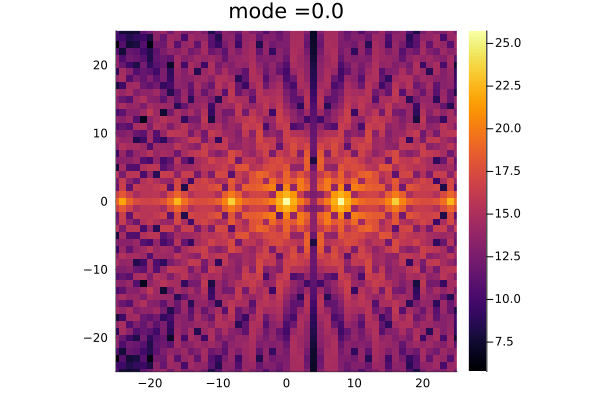

In [39]:
N = 2^10
p = 8
grating_blazed = blazed_grating(N, p)
t1 = transmission_func(grating_blazed)
T1 = fft2(t1)
t3 = transmission_func(grating_blazed)
T3 = fft2(t3)

k = 0
T3 = circshift(T3, (0, k))
k = k/p
K = T1 .* T3
K = abs.(K)
K_log = @. log(abs(K) + 1)
width = 50
x_heat = collect(-N÷2:N÷2-1)
y_heat = collect(-N÷2:N÷2-1)
zoom_heatmap(x_heat,y_heat,K_log, 50, colorbar=true, 
            title = "mode =$(k)",
            aspect_ratio = 1
)



8


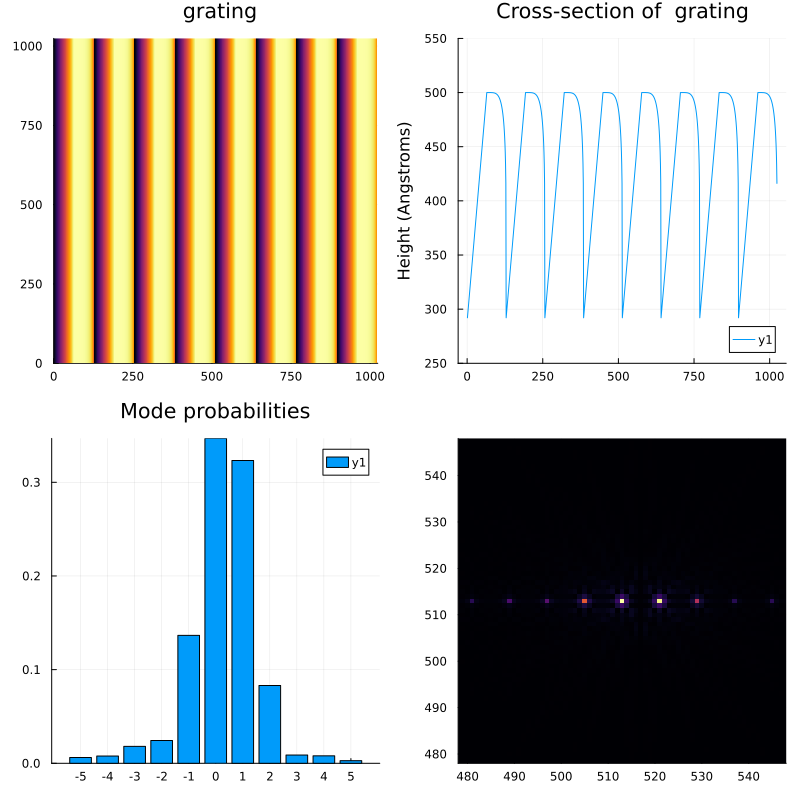

In [40]:
ellipse_blazed = ellipse_blazed_grating(N, p, 0.5, (5, 5); thickness=500, mill_depth=208)
plot_grating(ellipse_blazed)

4


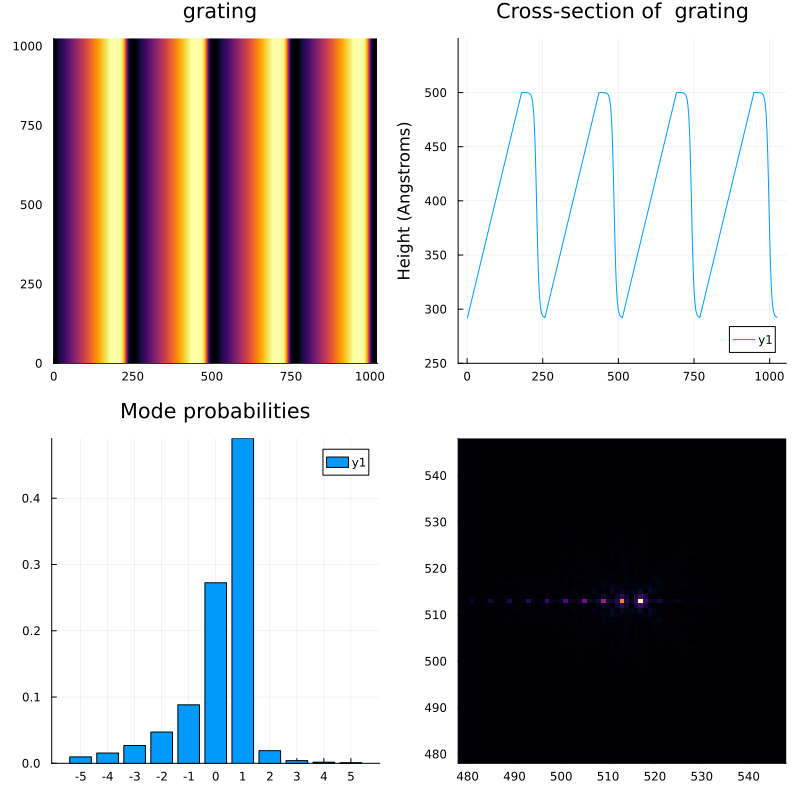

In [41]:
N=2^10
x_apex = 0.7
k = 30
p = 4
tanh_grating = tanh_blazed_grating(N, p, x_apex, k; mill_depth=178.5)[1]
tanh_grating = tanh_blazed_grating(N, p, x_apex, k; mill_depth=208)[1]

plot_grating(tanh_grating)

16


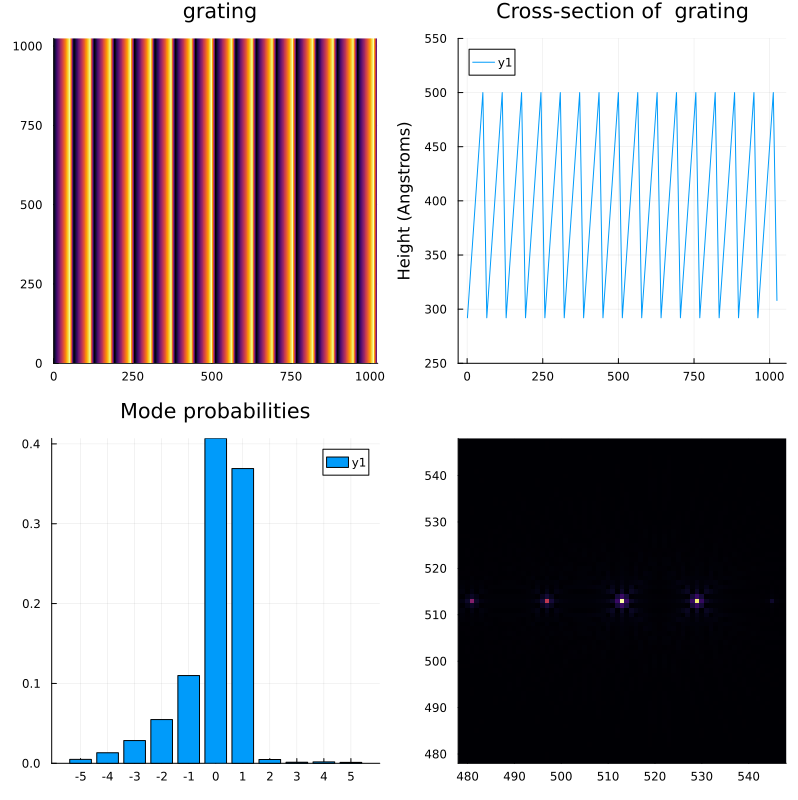

In [42]:
p = 16
grating_test = test_grating(N, p, .8; mill_depth=208)
# plot(grating_test[N÷2,:])
plot_grating(grating_test)

0.21311959858498666


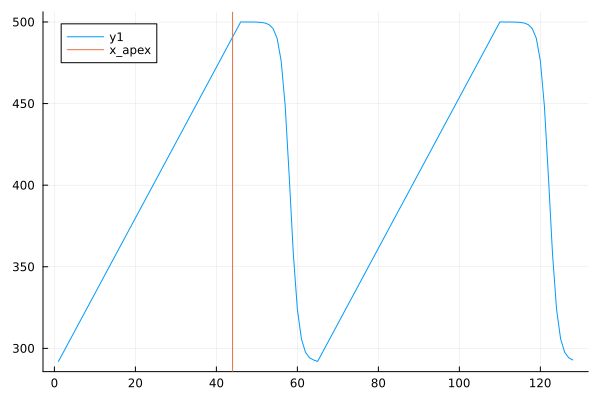

In [43]:
tanh_grating, x_width = tanh_blazed_grating(N, p, x_apex, k)[2]
println(x_width  )
plot(vcat(tanh_grating, tanh_grating))
x_shift = floor(Int, x_apex * ((N÷p) - 1))
vline!([x_shift], label="x_apex")

In [44]:
N = 2^10
p = 4
double_blazed = double_blazed_grating(N, p, 2p, 0.99; thickness=500, mill_depth=208)
# plot_grating(double_blazed)

1024×1008 Matrix{Float64}:
 292.0  300.667  309.333  318.0  326.667  …  -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667  …  -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     -176.0  -193.333  -210.667
   ⋮                                      ⋱     ⋮              
 292.0  300.667  309.333  318.0  326.667  …  -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     -176.0  -193.333  -210.667
 292.0  300.667  309.333  318.0  326.667     

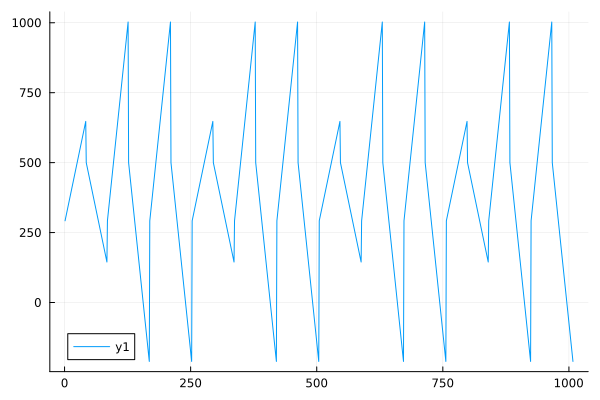

In [45]:
cross_section = double_blazed[N÷2+1, :]
plot(cross_section)

In [46]:
11÷2

5